Notebook réalisé par Anthony Sureau

## Imports

In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import tensorflow as tf
import itertools
import os
import glob
from google.colab import files
from google.colab import drive

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.impute import SimpleImputer
from sklearn.linear_model import LinearRegression, Ridge
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
from tensorflow.keras import layers, models
from tensorflow.keras.callbacks import EarlyStopping #Va nous permettre d'éviter l'overfitting

## Chargement des données


In [ ]:
drive.mount('/content/drive')

dossier = "/content/drive/MyDrive/redshift"
os.chdir(dossier)

# Lister tous les fichiers .npz du dossier
npz_files = glob.glob("*.npz")

# Filtrer uniquement les fichiers contenant "COSMOS"
cosmos_files = [f for f in npz_files if "COSMOS" in f]

# Charger chaque fichier dans un dictionnaire séparé
cosmos_data = {}
for fichier in cosmos_files:
    try:
        cosmos_data[fichier] = np.load(fichier, allow_pickle=True)
        print(f"Chargé : {fichier}")
    except Exception as e:
        print(f"Erreur lors du chargement de {fichier} : {e}")

# Afficher les clés et les shapes de chaque fichier séparément
for nom, data in cosmos_data.items():
    print(f"\n=== {nom} ===")
    for key in data.keys():
        print(f"  - {key} : {data[key].shape}")

# Séparer les fichiers COSMOS en deux groupes : spec et phot
spec_files = [f for f in cosmos_files if "spec" in f.lower()]
phot_files = [f for f in cosmos_files if "phot" in f.lower()]

print("Fichiers SPEC:", spec_files)
print("Fichiers PHOT:", phot_files)

# Charger les données spec
spec_data = np.load(spec_files[0], allow_pickle=True)

# Charger les données phot
phot_data = np.load(phot_files[0], allow_pickle=True)

# Extraire les infos
spec_info = spec_data["info"]
phot_info = phot_data["info"]

# Convertir en DataFrame pandas
spec_df = pd.DataFrame(spec_info)
phot_df = pd.DataFrame(phot_info)

# Renommer les colonnes cibles
spec_df = spec_df.rename(columns={"ZSPEC": "redshift"})
phot_df = phot_df.rename(columns={"ZPHOT": "redshift"})

# Vérifier
print("Colonnes SPEC:", spec_df.columns.tolist())
print("Colonnes PHOT:", phot_df.columns.tolist())

# Garder uniquement les magnitudes
magnitudes = ['u', 'g', 'r', 'i', 'z', 'y', 'EBV']

spec_mag = spec_df[magnitudes + ['redshift']].copy()
phot_mag = phot_df[magnitudes + ['redshift']].copy()

# Créer les couleurs
for df in [spec_mag, phot_mag]:
    df['u_g'] = df['u'] - df['g']
    df['g_r'] = df['g'] - df['r']
    df['r_i'] = df['r'] - df['i']
    df['i_z'] = df['i'] - df['z']
    df['z_y'] = df['z'] - df['y']

# Filtrer les données
#spec_mag = spec_mag[spec_mag['redshift'] <= 1].copy()
#phot_mag = phot_mag[phot_mag['redshift'] <= 1].copy()

# Nettoyage des -99
magnitudes = ['u', 'g', 'r', 'i', 'z', 'y', 'EBV']
#for df_name, df in [('spec_mag', spec_mag), ('phot_mag', phot_mag)]:
    #df.replace(-99, np.nan, inplace=True)
    #for col in magnitudes:
        #df.loc[df[col] < -90, col] = np.nan

spec_mag = spec_mag.dropna(subset=magnitudes).copy()
phot_mag = phot_mag.dropna(subset=magnitudes).copy()

# Recalculer les couleurs après nettoyage
for df in [spec_mag, phot_mag]:
    df['u_g'] = df['u'] - df['g']
    df['g_r'] = df['g'] - df['r']
    df['r_i'] = df['r'] - df['i']
    df['i_z'] = df['i'] - df['z']
    df['z_y'] = df['z'] - df['y']

print(f"SPEC après nettoyage : {len(spec_mag)} objets")
print(f"PHOT après nettoyage : {len(phot_mag)} objets")

Mounted at /content/drive
Chargé : COSMOS_v11_uijk_0001_photo_D.npz
Chargé : COSMOS_v11_uijk_0213_photo_UD.npz
Chargé : COSMOS_v11_uijk_0020_spec_D.npz
Chargé : COSMOS_v11_uijk_0073_spec_UD.npz

=== COSMOS_v11_uijk_0001_photo_D.npz ===
  - cube : (12054, 64, 64, 9)
  - info : (12054,)
  - flag : (12054, 9)

=== COSMOS_v11_uijk_0213_photo_UD.npz ===
  - cube : (443, 64, 64, 9)
  - info : (443,)
  - flag : (443, 9)

=== COSMOS_v11_uijk_0020_spec_D.npz ===
  - cube : (15, 64, 64, 9)
  - info : (15,)
  - flag : (15, 9)

=== COSMOS_v11_uijk_0073_spec_UD.npz ===
  - cube : (12, 64, 64, 9)
  - info : (12,)
  - flag : (12, 9)
Fichiers SPEC: ['COSMOS_v11_uijk_0020_spec_D.npz', 'COSMOS_v11_uijk_0073_spec_UD.npz']
Fichiers PHOT: ['COSMOS_v11_uijk_0001_photo_D.npz', 'COSMOS_v11_uijk_0213_photo_UD.npz']
Colonnes SPEC: ['ID', 'RA', 'DEC', 'TRACT', 'PATCH', 'MASK', 'FLAG_FIELD', 'EB_V', 'CLASS_STAR_HSC_I', 'u', 'uS', 'g', 'r', 'i', 'z', 'y', 'J', 'H', 'Ks', 'u_err', 'uS_err', 'g_err', 'r_err', 'i_err

## Préparation des données images pour le CNN

In [ ]:
# Normalisation des images

def custom_norm(x):
    return np.sign(x) * np.sqrt(np.abs(x) + 1) - 1

# Train + Calib : données PHOT (deux fichiers combinés)

X_phot_list = []
y_phot_list = []
for f in phot_files:
    d    = cosmos_data[f]
    info = pd.DataFrame(d['info'])
    zp   = info['ZPHOT'].values.astype(np.float32)
    cube = d['cube'].astype(np.float32)
    mask = np.isfinite(zp) & (zp > 0)
    X_phot_list.append(custom_norm(cube[mask]))
    y_phot_list.append(zp[mask])
X_phot = np.concatenate(X_phot_list, axis=0)
y_phot = np.concatenate(y_phot_list, axis=0)

# Split phot en train + calib (ZPHOT comme vérité)

X_train, X_calib, y_train, y_calib = train_test_split(
    X_phot, y_phot, test_size=0.3, random_state=42
)

# Test : données SPEC (ZSPEC comme vérité terrain)

X_spec_list = []
y_spec_list = []

for f in spec_files:
    d    = cosmos_data[f]
    info = pd.DataFrame(d['info'])
    zs   = info['ZSPEC'].values.astype(np.float32)
    cube = d['cube'].astype(np.float32)

    mask = np.isfinite(zs) & (zs > 0)
    X_spec_list.append(custom_norm(cube[mask]))
    y_spec_list.append(zs[mask])

X_test = np.concatenate(X_spec_list, axis=0)
y_test = np.concatenate(y_spec_list, axis=0)

print(f"Train      : {len(X_train)} objets  (phot / ZPHOT)")
print(f"Calibration: {len(X_calib)} objets  (phot / ZPHOT)")
print(f"Test       : {len(X_test)} objets   (spec / ZSPEC)")

Train      : 8747 objets  (phot / ZPHOT)
Calibration: 3750 objets  (phot / ZPHOT)
Test       : 27 objets   (spec / ZSPEC)


## Architecture et entraînement du CNN

CNN entraîné sur les images phot, avec EarlyStopping pour éviter l'overfitting.

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d (Conv2D)                 │ (None, 64, 64, 32)     │         2,624 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 32, 32, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 32, 32, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 16, 16, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_2 (Conv2D)               │ (None, 16, 16, 128)    │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_average_pooling2d        │ (None, 128)            │             0 │
│ (GlobalAveragePooling2D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 128)            │        16,512 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 1)              │           129 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 111,617 (436.00 KB)

 Trainable params: 111,617 (436.00 KB)

 Non-trainable params: 0 (0.00 B)

Epoch 1/30
246/246 ━━━━━━━━━━━━━━━━━━━━ 10s 16ms/step - loss: 0.8401 - mae: 0.7040 - val_loss: 0.7534 - val_mae: 0.6669
Epoch 2/30
246/246 ━━━━━━━━━━━━━━━━━━━━ 2s 8ms/step - loss: 0.7875 - mae: 0.6816 - val_loss: 0.7603 - val_mae: 0.6770
Epoch 3/30
246/246 ━━━━━━━━━━━━━━━━━━━━ 2s 8ms/step - loss: 0.7845 - mae: 0.6814 - val_loss: 0.7710 - val_mae: 0.6865
Epoch 4/30
246/246 ━━━━━━━━━━━━━━━━━━━━ 2s 8ms/step - loss: 0.7851 - mae: 0.6798 - val_loss: 0.7288 - val_mae: 0.6526
Epoch 5/30
246/246 ━━━━━━━━━━━━━━━━━━━━ 2s 8ms/step - loss: 0.7564 - mae: 0.6647 - val_loss: 0.7050 - val_mae: 0.6281
Epoch 6/30
246/246 ━━━━━━━━━━━━━━━━━━━━ 3s 10ms/step - loss: 0.7340 - mae: 0.6549 - val_loss: 0.6993 - val_mae: 0.6505
Epoch 7/30
246/246 ━━━━━━━━━━━━━━━━━━━━ 2s 10ms/step - loss: 0.7249 - mae: 0.6502 - val_loss: 0.6854 - val_mae: 0.6364
Epoch 8/30
246/246 ━━━━━━━━━━━━━━━━━━━━ 2s 8ms/step - loss: 0.7205 - mae: 0.6468 - val_loss: 0.6644 - val_mae: 0.6165
Epoch 9/30
246/246 ━━━━━━━━━━━━━━━━━━━━ 2s 8ms/step 

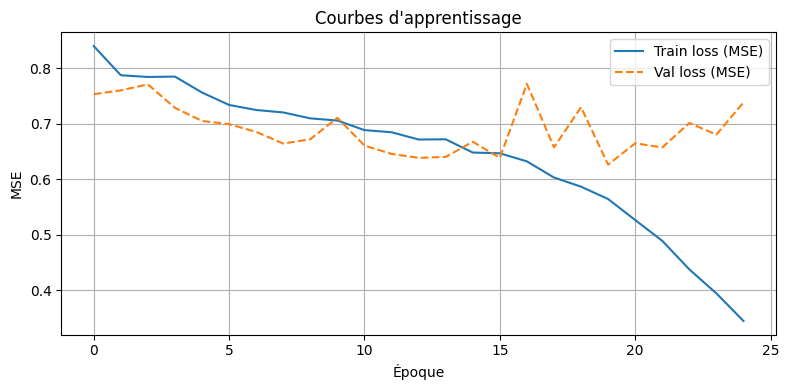

In [ ]:
model = models.Sequential([
    layers.Input(shape=(64, 64, 9)),
    layers.Conv2D(32, 3, activation='relu', padding='same'),
    layers.MaxPooling2D(),
    layers.Conv2D(64, 3, activation='relu', padding='same'),
    layers.MaxPooling2D(),
    layers.Conv2D(128, 3, activation='relu', padding='same'),
    layers.GlobalAveragePooling2D(),
    layers.Dense(128, activation='relu'),
    layers.Dropout(0.3),
    layers.Dense(1)
])

model.compile(optimizer='adam', loss='mse', metrics=['mae'])
model.summary()

# Entraînement

early_stop = EarlyStopping(
    monitor='val_loss',
    patience=5,
    restore_best_weights=True,
    verbose=1
)

history = model.fit(
    X_train, y_train,
    epochs=30,
    batch_size=32,
    validation_split=0.1,
    callbacks=[early_stop],
    verbose=1
)

# Courbe d'apprentissage

plt.figure(figsize=(8, 4))
plt.plot(history.history['loss'],     label='Train loss (MSE)')
plt.plot(history.history['val_loss'], label='Val loss (MSE)', linestyle='--')
plt.xlabel("Époque"); plt.ylabel("MSE")
plt.title("Courbes d'apprentissage")
plt.legend(); plt.grid(True)
plt.tight_layout()
plt.show()

 Métriques CNN sur données spec 
  N objets spec      : 27
  MAE (Δz brut)      : 1.1566
  Biais              : -0.1899
  NMAD               : 0.7555
  Taux outliers η    : 0.889  (|Δz/(1+z)| > 0.15)


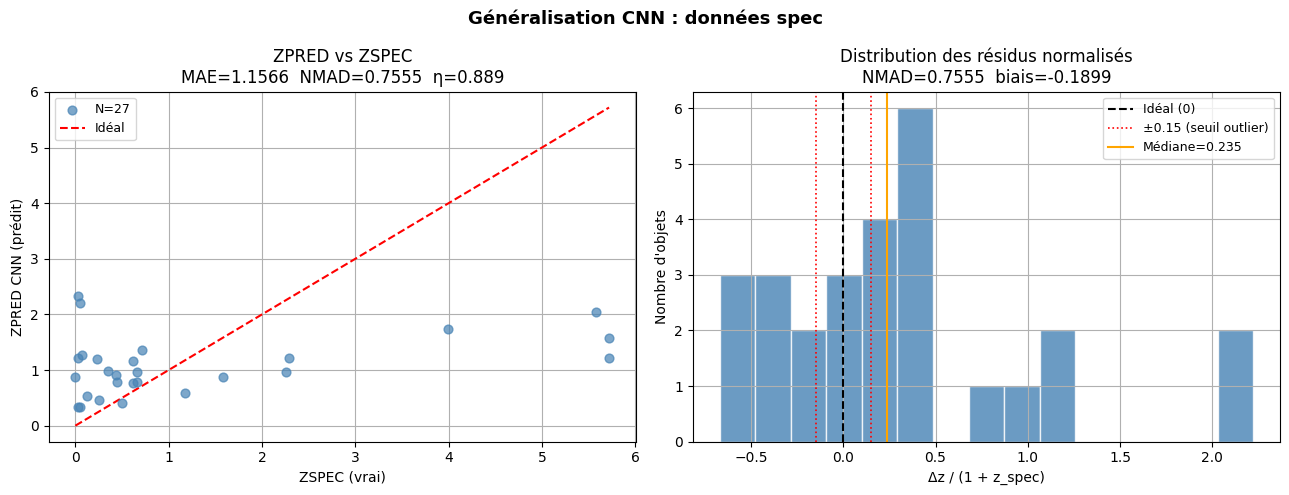

In [ ]:
# Evaluation du CNN sur les données spec

# Prédictions sur tout le set spec (calib + test)

z_pred_all = model.predict(X_test, verbose=0).squeeze()
z_true_all = y_test

dz_norm = (z_pred_all - z_true_all) / (1 + z_true_all)
mae     = np.mean(np.abs(z_pred_all - z_true_all))
bias    = np.mean(z_pred_all - z_true_all)
nmad    = 1.4826 * np.median(np.abs(dz_norm - np.median(dz_norm)))
eta     = np.mean(np.abs(dz_norm) > 0.15)

print(" Métriques CNN sur données spec ")
print(f"  N objets spec      : {len(z_true_all)}")
print(f"  MAE (Δz brut)      : {mae:.4f}")
print(f"  Biais              : {bias:.4f}")
print(f"  NMAD               : {nmad:.4f}")
print(f"  Taux outliers η    : {eta:.3f}  (|Δz/(1+z)| > 0.15)")

fig, axes = plt.subplots(1, 2, figsize=(13, 5))
fig.suptitle("Généralisation CNN : données spec", fontsize=13, fontweight='bold')

ax = axes[0]
ax.scatter(z_true_all, z_pred_all, s=40, alpha=0.7, color='steelblue', zorder=3, label=f"N={len(z_true_all)}")
zmax = max(z_true_all.max(), z_pred_all.max())
ax.plot([0, zmax], [0, zmax], 'r--', lw=1.5, label='Idéal')
ax.set_xlabel("ZSPEC (vrai)")
ax.set_ylabel("ZPRED CNN (prédit)")
ax.set_title(f"ZPRED vs ZSPEC\nMAE={mae:.4f}  NMAD={nmad:.4f}  η={eta:.3f}")
ax.legend(fontsize=9); ax.grid(True)

ax = axes[1]
ax.hist(dz_norm, bins=15, color='steelblue', edgecolor='white', alpha=0.8)
ax.axvline(0,     color='black', lw=1.5, ls='--', label='Idéal (0)')
ax.axvline( 0.15, color='red',   lw=1.2, ls=':',  label='±0.15 (seuil outlier)')
ax.axvline(-0.15, color='red',   lw=1.2, ls=':')
ax.axvline(np.median(dz_norm), color='orange', lw=1.5, label=f"Médiane={np.median(dz_norm):.3f}")
ax.set_xlabel("Δz / (1 + z_spec)")
ax.set_ylabel("Nombre d'objets")
ax.set_title(f"Distribution des résidus normalisés\nNMAD={nmad:.4f}  biais={bias:.4f}")
ax.legend(fontsize=9); ax.grid(True)

plt.tight_layout()
plt.show()


## Prédictions CNN sur les images spec

In [ ]:
# Prédictions sur le set de calibration (phot/ZPHOT) et le set de test (spec/ZSPEC)

z_pred_calib = model.predict(X_calib, verbose=0).squeeze()
z_pred_test  = model.predict(X_test,  verbose=0).squeeze()

# Vérité terrain

z_true_calib = y_calib #ZPHOT
z_true_test  = y_test #ZSPEC

print(f"Prédictions calib : {len(z_pred_calib)} objets")
print(f"Prédictions test  : {len(z_pred_test)} objets")
print(f"ZPRED calib -> min={z_pred_calib.min():.3f}  max={z_pred_calib.max():.3f}")
print(f"ZSPEC calib -> min={z_true_calib.min():.3f}  max={z_true_calib.max():.3f}")

# Niveaux de confiance à tester

alphas = [0.05, 0.10, 0.15, 0.20]

Prédictions calib : 3750 objets
Prédictions test  : 27 objets
ZPRED calib → min=0.311  max=2.994
ZSPEC calib → min=0.016  max=5.848


## Première approche : Résidus directs  |ZPRED - ZSPEC|

Correspondant au score de non-conformité, résidu absolu entre la prédiction CNN et la vérité ZSPEC

In [ ]:
print("APPROCHE 1 : Résidus directs  |ZPRED - ZSPEC|")

scores_1 = np.abs(z_pred_calib - z_true_calib)

results_1 = {}
print(f"\n{'α':>6} | {'q_hat':>8} | {'Couverture':>12} | {'Largeur':>10}")
print("-" * 45)
for alpha in alphas:
    q     = np.quantile(scores_1, 1 - alpha)
    low   = z_pred_test - q
    high  = z_pred_test + q
    cov   = np.mean((z_true_test >= low) & (z_true_test <= high))
    width = 2 * q
    results_1[alpha] = dict(q_hat=q, coverage=cov, width=width, lower=low, upper=high)
    print(f"{alpha:>6.2f} | {q:>8.4f} | {cov:>12.3f} | {width:>10.4f}")

APPROCHE 1 : Résidus directs  |ZPRED - ZSPEC|

     α |    q_hat |   Couverture |    Largeur
---------------------------------------------
  0.05 |   1.6181 |        0.778 |     3.2361
  0.10 |   1.3289 |        0.778 |     2.6578
  0.15 |   1.1342 |        0.667 |     2.2683
  0.20 |   1.0084 |        0.630 |     2.0168


## Deuxième approche : Bins de redshift (largeur 0.1)

On discrétise z en bins de largeur 0.1 et on mesure l'écart en nombre de bins
entre la prédiction CNN et la vérité ZSPEC.

In [ ]:
print("APPROCHE 2 : Bins de redshift (largeur 0.1)")

bins   = np.arange(0, 4.1, 0.1)
n_bins = len(bins) - 1

def to_bin(z):
    return np.clip(np.digitize(z, bins) - 1, 0, n_bins - 1)

scores_2 = np.abs(to_bin(z_pred_calib) - to_bin(z_true_calib))

results_2 = {}
print(f"\n{'α':>6} | {'k_hat':>8} | {'Couverture':>12} | {'Largeur Δz':>12}")
print("-" * 48)
for alpha in alphas:
    k     = int(np.ceil(np.quantile(scores_2, 1 - alpha)))
    b_p   = to_bin(z_pred_test)
    low_b = np.clip(b_p - k, 0, n_bins - 1)
    hig_b = np.clip(b_p + k, 0, n_bins - 1)
    low   = bins[low_b]
    high  = bins[np.minimum(hig_b + 1, n_bins)]
    cov   = np.mean((z_true_test >= low) & (z_true_test <= high))
    width = np.mean(high - low)
    results_2[alpha] = dict(k_hat=k, coverage=cov, width=width, lower=low, upper=high)
    print(f"{alpha:>6.2f} | {k:>8d} | {cov:>12.3f} | {width:>12.4f}")

APPROCHE 2 : Bins de redshift (largeur 0.1)

     α |    k_hat |   Couverture |   Largeur Δz
------------------------------------------------
  0.05 |       16 |        0.778 |       2.6630
  0.10 |       13 |        0.778 |       2.3111
  0.15 |       11 |        0.667 |       2.0481
  0.20 |       10 |        0.667 |       1.9037


## Troisième approche : Δz normalisé  (z_pred − z_spec) / (1 + z_spec)

Score standard en astronomie pour les photo-z.
Normalise l'erreur par (1 + z) pour tenir compte de l'expansion cosmique.

In [ ]:
print("APPROCHE 3 : Δz = (ZPRED - ZSPEC) / (1 + ZSPEC)")

scores_3 = np.abs((z_pred_calib - z_true_calib) / (1 + z_true_calib))

results_3 = {}
print(f"\n{'α':>6} | {'q_hat':>8} | {'Couverture':>12} | {'Outliers':>10}")
print("-" * 45)
for alpha in alphas:
    q    = np.quantile(scores_3, 1 - alpha)
    dz   = np.abs((z_pred_test - z_true_test) / (1 + z_true_test))
    cov  = np.mean(dz <= q)
    out  = np.mean(dz > 0.15)
    low  = z_pred_test - q * (1 + z_true_test)
    high = z_pred_test + q * (1 + z_true_test)
    results_3[alpha] = dict(q_hat=q, coverage=cov, outliers=out,
                            dz_test=dz, lower=low, upper=high)
    print(f"{alpha:>6.2f} | {q:>8.4f} | {cov:>12.3f} | {out:>10.3f}")

APPROCHE 3 : Δz = (ZPRED - ZSPEC) / (1 + ZSPEC)

     α |    q_hat |   Couverture |   Outliers
---------------------------------------------
  0.05 |   0.7595 |        0.778 |      0.889
  0.10 |   0.5447 |        0.704 |      0.889
  0.15 |   0.4471 |        0.593 |      0.889
  0.20 |   0.3807 |        0.556 |      0.889


## Figures comparaison des 3 approches

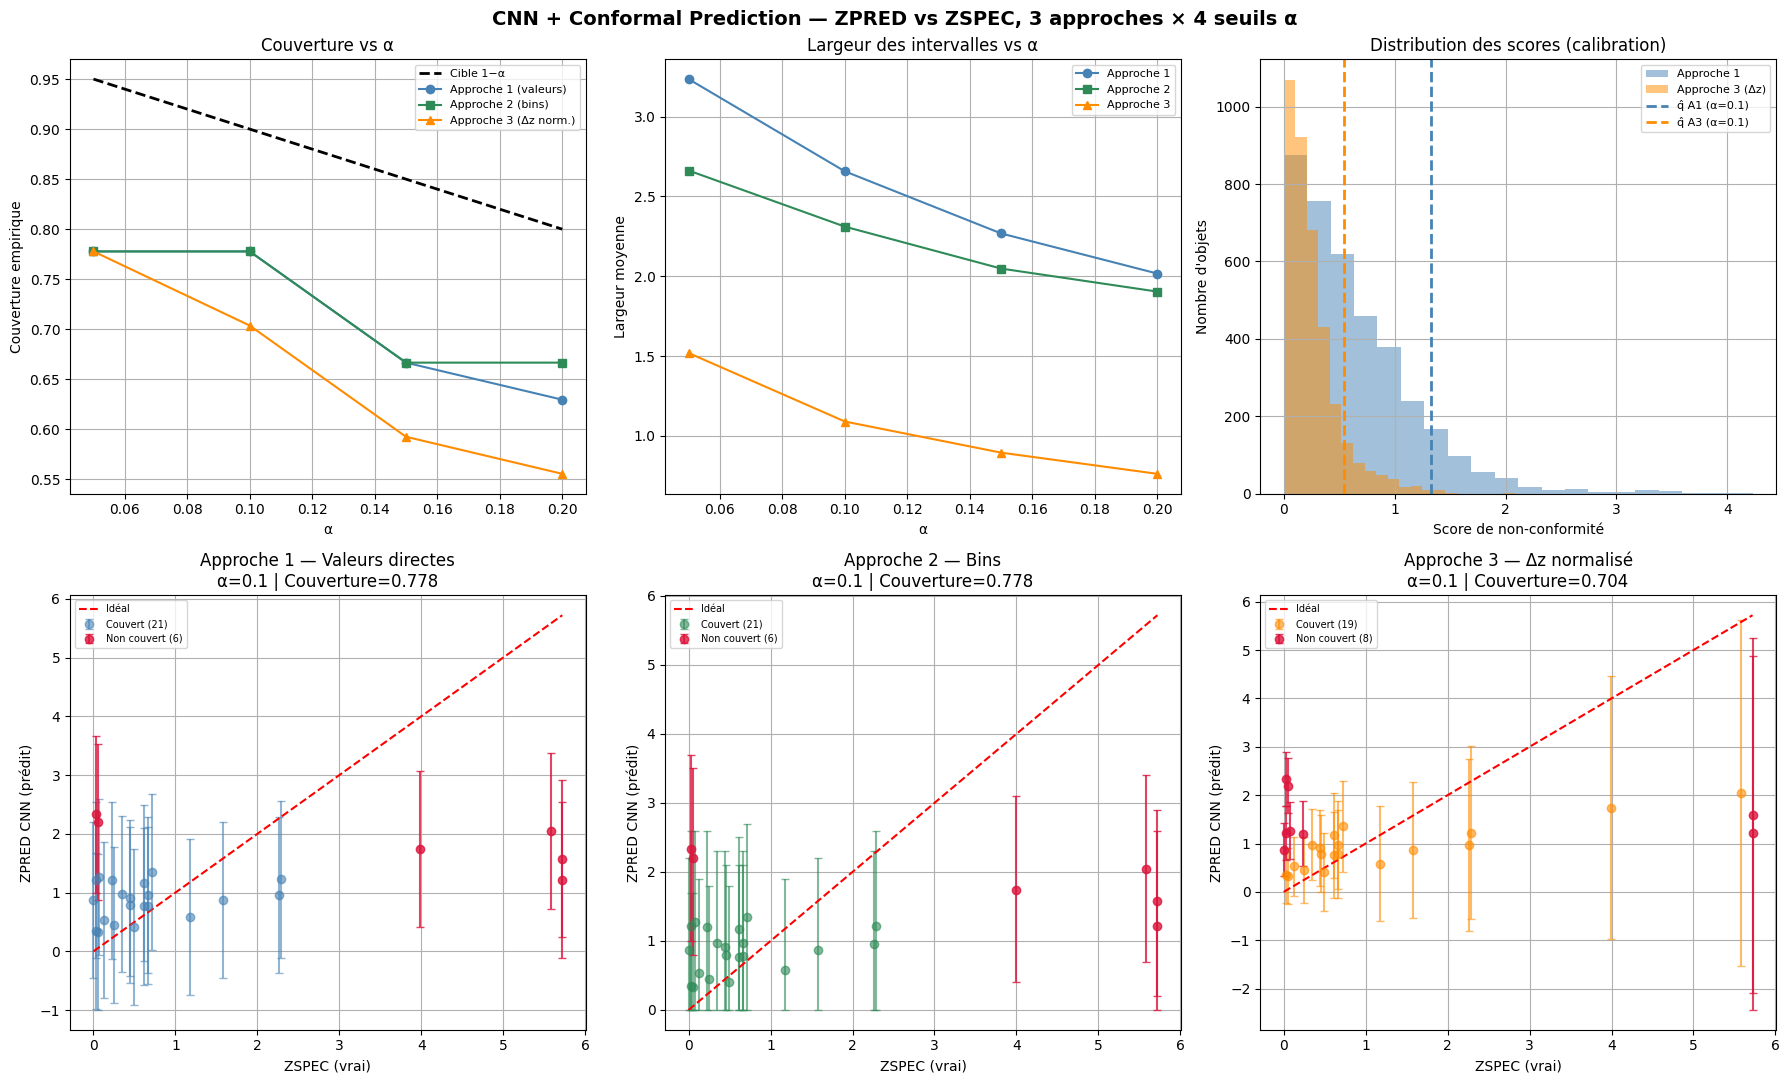

In [ ]:
fig, axes = plt.subplots(2, 3, figsize=(18, 11))
fig.suptitle(
    "CNN + Conformal Prediction - ZPRED vs ZSPEC, 3 approches × 4 seuils α",
    fontsize=14, fontweight='bold'
)

alpha_ref = 0.10

# Ligne 1 : métriques globales

# (0,0) Couverture vs α

ax = axes[0, 0]
cov1 = [results_1[a]['coverage'] for a in alphas]
cov2 = [results_2[a]['coverage'] for a in alphas]
cov3 = [results_3[a]['coverage'] for a in alphas]
ax.plot(alphas, [1 - a for a in alphas], 'k--', lw=2, label='Cible 1−α')
ax.plot(alphas, cov1, 'o-', color='steelblue',  label='Approche 1 (valeurs)')
ax.plot(alphas, cov2, 's-', color='seagreen',   label='Approche 2 (bins)')
ax.plot(alphas, cov3, '^-', color='darkorange', label='Approche 3 (Δz norm.)')
ax.set_xlabel("α"); ax.set_ylabel("Couverture empirique")
ax.set_title("Couverture vs α")
ax.legend(fontsize=8); ax.grid(True)

# (0,1) Largeur des intervalles vs α

ax = axes[0, 1]
w1 = [results_1[a]['width']     for a in alphas]
w2 = [results_2[a]['width']     for a in alphas]
w3 = [results_3[a]['q_hat'] * 2 for a in alphas]
ax.plot(alphas, w1, 'o-', color='steelblue',  label='Approche 1')
ax.plot(alphas, w2, 's-', color='seagreen',   label='Approche 2')
ax.plot(alphas, w3, '^-', color='darkorange', label='Approche 3')
ax.set_xlabel("α"); ax.set_ylabel("Largeur moyenne")
ax.set_title("Largeur des intervalles vs α")
ax.legend(fontsize=8); ax.grid(True)

# (0,2) Distribution des scores de calibration

ax = axes[0, 2]
ax.hist(scores_1, bins=20, alpha=0.5, color='steelblue',  label='Approche 1')
ax.hist(scores_3, bins=20, alpha=0.5, color='darkorange', label='Approche 3 (Δz)')
ax.axvline(results_1[alpha_ref]['q_hat'], color='steelblue',  ls='--', lw=2,
           label=f"q̂ A1 (α={alpha_ref})")
ax.axvline(results_3[alpha_ref]['q_hat'], color='darkorange', ls='--', lw=2,
           label=f"q̂ A3 (α={alpha_ref})")
ax.set_xlabel("Score de non-conformité")
ax.set_ylabel("Nombre d'objets")
ax.set_title("Distribution des scores (calibration)")
ax.legend(fontsize=8); ax.grid(True)

# Ligne 2 : ZPRED vs ZSPEC pour chaque approche (α=0.10)

configs = [
    (results_1, "Approche 1 - Valeurs directes", "steelblue"),
    (results_2, "Approche 2 - Bins",             "seagreen"),
    (results_3, "Approche 3 - Δz normalisé",     "darkorange"),
]
for col_idx, (results, label, color) in enumerate(configs):
    ax  = axes[1, col_idx]
    r   = results[alpha_ref]
    low, high = r['lower'], r['upper']
    covered   = (z_true_test >= low) & (z_true_test <= high)
    yerr = np.array([
        np.maximum(z_pred_test - low, 0),
        np.maximum(high - z_pred_test, 0)
        ])


    ax.errorbar(
        z_true_test[covered],  z_pred_test[covered],
        yerr=[yerr[0][covered],  yerr[1][covered]],
        fmt='o', alpha=0.6, capsize=3, color=color,
        label=f'Couvert ({covered.sum()})'
    )
    ax.errorbar(
        z_true_test[~covered], z_pred_test[~covered],
        yerr=[yerr[0][~covered], yerr[1][~covered]],
        fmt='o', alpha=0.8, capsize=3, color='crimson',
        label=f'Non couvert ({(~covered).sum()})'
    )
    zmax = max(z_true_test.max(), z_pred_test.max())
    ax.plot([0, zmax], [0, zmax], 'r--', lw=1.5, label='Idéal')
    ax.set_xlabel("ZSPEC (vrai)"); ax.set_ylabel("ZPRED CNN (prédit)")
    ax.set_title(f"{label}\nα={alpha_ref} | Couverture={r['coverage']:.3f}")
    ax.legend(fontsize=7); ax.grid(True)

plt.tight_layout()
plt.show()

#Télécharger les graphiques

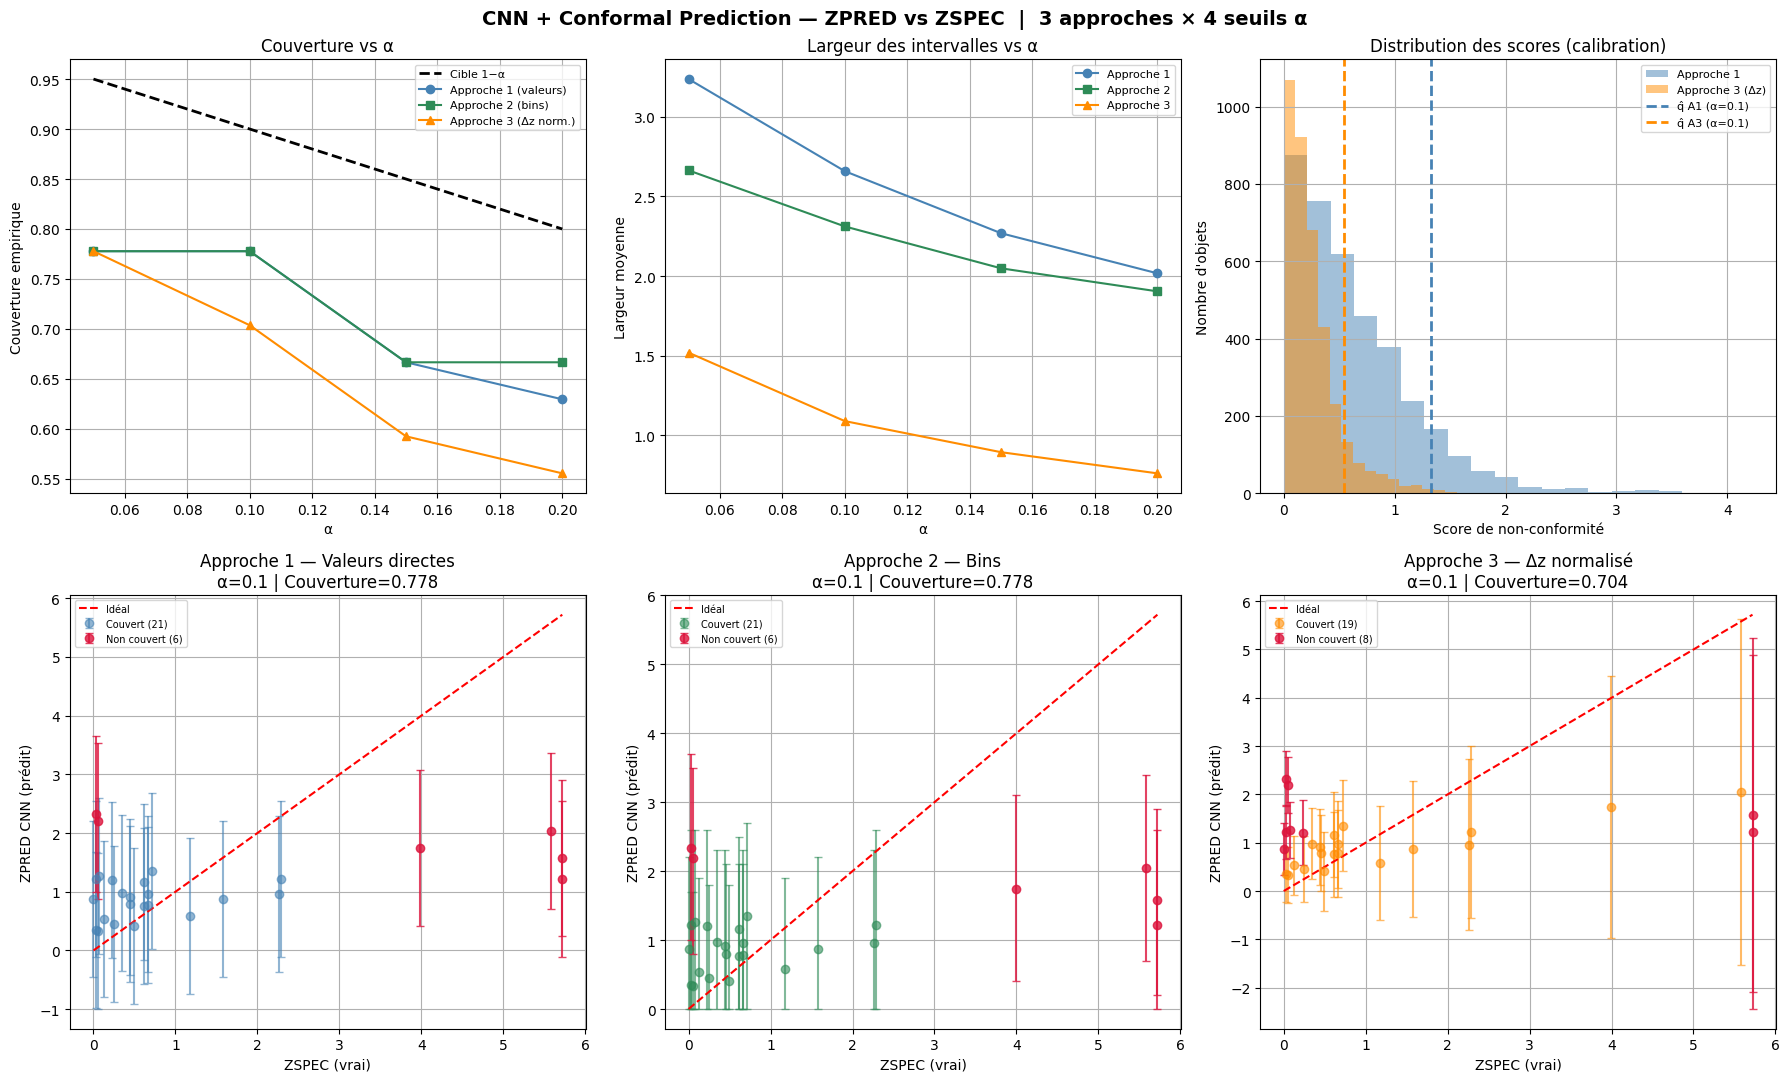

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

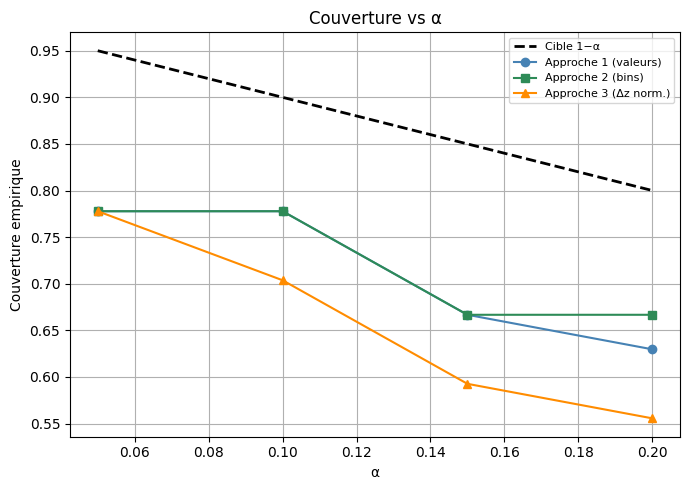

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

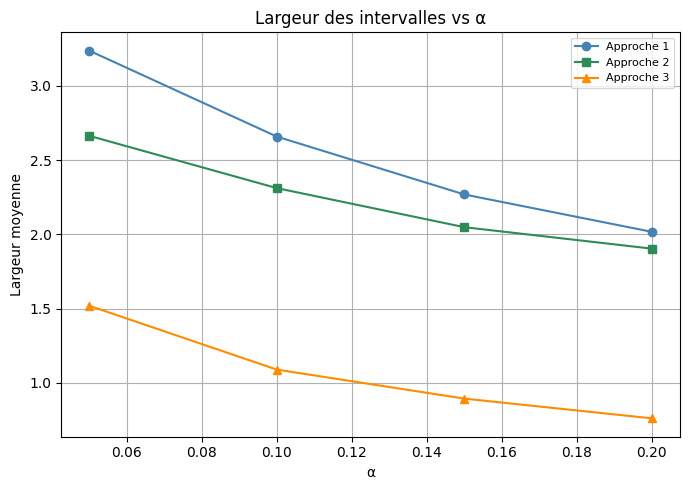

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

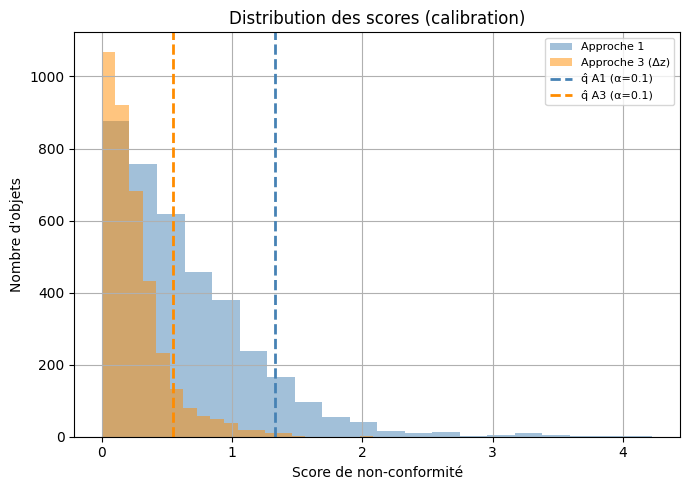

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

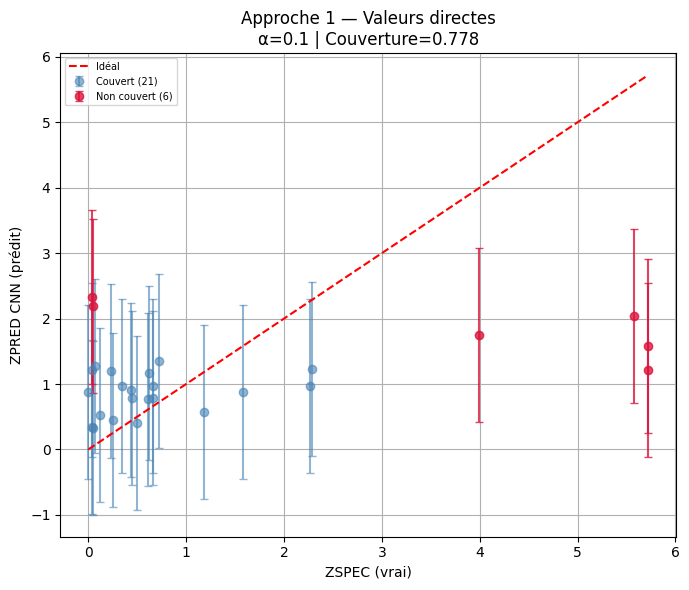

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

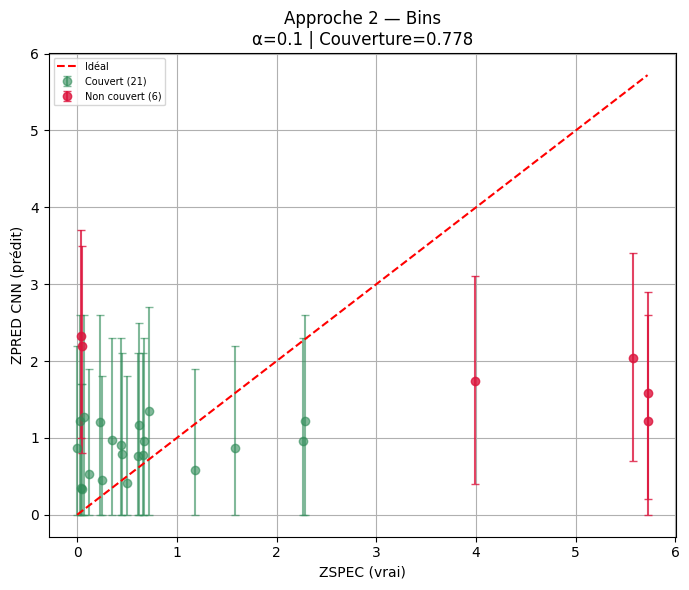

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

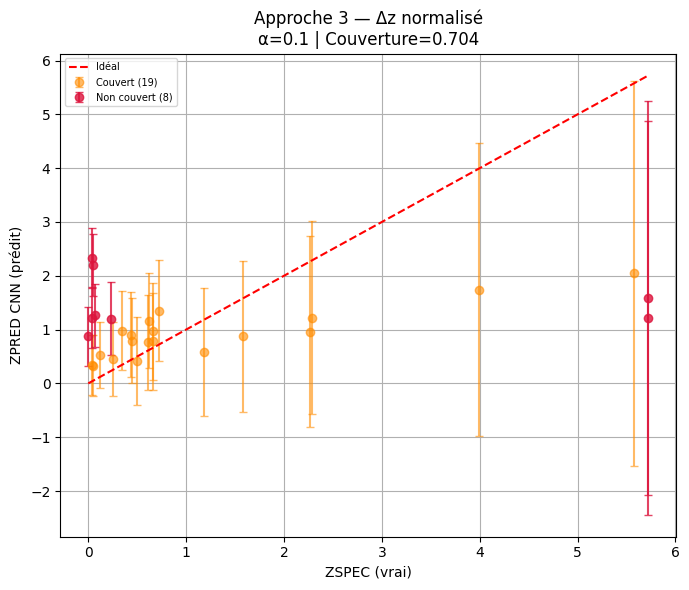

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

In [ ]:
fig, axes = plt.subplots(2, 3, figsize=(18, 11))
fig.suptitle(
    "CNN + Conformal Prediction - ZPRED vs ZSPEC  |  3 approches × 4 seuils α",
    fontsize=14, fontweight='bold'
)

alpha_ref = 0.10

# (0,0) Couverture vs α

ax = axes[0, 0]
cov1 = [results_1[a]['coverage'] for a in alphas]
cov2 = [results_2[a]['coverage'] for a in alphas]
cov3 = [results_3[a]['coverage'] for a in alphas]
ax.plot(alphas, [1 - a for a in alphas], 'k--', lw=2, label='Cible 1−α')
ax.plot(alphas, cov1, 'o-', color='steelblue',  label='Approche 1 (valeurs)')
ax.plot(alphas, cov2, 's-', color='seagreen',   label='Approche 2 (bins)')
ax.plot(alphas, cov3, '^-', color='darkorange', label='Approche 3 (Δz norm.)')
ax.set_xlabel("α"); ax.set_ylabel("Couverture empirique")
ax.set_title("Couverture vs α")
ax.legend(fontsize=8); ax.grid(True)

# (0,1) Largeur des intervalles vs α

ax = axes[0, 1]
w1 = [results_1[a]['width']     for a in alphas]
w2 = [results_2[a]['width']     for a in alphas]
w3 = [results_3[a]['q_hat'] * 2 for a in alphas]
ax.plot(alphas, w1, 'o-', color='steelblue',  label='Approche 1')
ax.plot(alphas, w2, 's-', color='seagreen',   label='Approche 2')
ax.plot(alphas, w3, '^-', color='darkorange', label='Approche 3')
ax.set_xlabel("α"); ax.set_ylabel("Largeur moyenne")
ax.set_title("Largeur des intervalles vs α")
ax.legend(fontsize=8); ax.grid(True)

# (0,2) Distribution des scores de calibration

ax = axes[0, 2]
ax.hist(scores_1, bins=20, alpha=0.5, color='steelblue',  label='Approche 1')
ax.hist(scores_3, bins=20, alpha=0.5, color='darkorange', label='Approche 3 (Δz)')
ax.axvline(results_1[alpha_ref]['q_hat'], color='steelblue',  ls='--', lw=2,
           label=f"q̂ A1 (α={alpha_ref})")
ax.axvline(results_3[alpha_ref]['q_hat'], color='darkorange', ls='--', lw=2,
           label=f"q̂ A3 (α={alpha_ref})")
ax.set_xlabel("Score de non-conformité")
ax.set_ylabel("Nombre d'objets")
ax.set_title("Distribution des scores (calibration)")
ax.legend(fontsize=8); ax.grid(True)

# Ligne 2 : ZPRED vs ZSPEC pour chaque approche (α=0.10)

configs = [
    (results_1, "Approche 1 - Valeurs directes", "steelblue"),
    (results_2, "Approche 2 - Bins",             "seagreen"),
    (results_3, "Approche 3 - Δz normalisé",     "darkorange"),
]
for col_idx, (results, label, color) in enumerate(configs):
    ax  = axes[1, col_idx]
    r   = results[alpha_ref]
    low, high = r['lower'], r['upper']
    covered   = (z_true_test >= low) & (z_true_test <= high)
    yerr = np.array([
        np.maximum(z_pred_test - low, 0),
        np.maximum(high - z_pred_test, 0)
    ])
    ax.errorbar(
        z_true_test[covered],  z_pred_test[covered],
        yerr=[yerr[0][covered],  yerr[1][covered]],
        fmt='o', alpha=0.6, capsize=3, color=color,
        label=f'Couvert ({covered.sum()})'
    )
    ax.errorbar(
        z_true_test[~covered], z_pred_test[~covered],
        yerr=[yerr[0][~covered], yerr[1][~covered]],
        fmt='o', alpha=0.8, capsize=3, color='crimson',
        label=f'Non couvert ({(~covered).sum()})'
    )
    zmax = max(z_true_test.max(), z_pred_test.max())
    ax.plot([0, zmax], [0, zmax], 'r--', lw=1.5, label='Idéal')
    ax.set_xlabel("ZSPEC (vrai)"); ax.set_ylabel("ZPRED CNN (prédit)")
    ax.set_title(f"{label}\nα={alpha_ref} | Couverture={r['coverage']:.3f}")
    ax.legend(fontsize=7); ax.grid(True)

plt.tight_layout()
plt.savefig("cnn_conformal_complet.png", dpi=150, bbox_inches='tight')
plt.show()
files.download("cnn_conformal_complet.png")

# Téléchargement de chaque sous-graphique séparément

# Sous-graphique 1 : Couverture vs α

fig_s1, ax_s1 = plt.subplots(figsize=(7, 5))
ax_s1.plot(alphas, [1 - a for a in alphas], 'k--', lw=2, label='Cible 1−α')
ax_s1.plot(alphas, cov1, 'o-', color='steelblue',  label='Approche 1 (valeurs)')
ax_s1.plot(alphas, cov2, 's-', color='seagreen',   label='Approche 2 (bins)')
ax_s1.plot(alphas, cov3, '^-', color='darkorange', label='Approche 3 (Δz norm.)')
ax_s1.set_xlabel("α"); ax_s1.set_ylabel("Couverture empirique")
ax_s1.set_title("Couverture vs α")
ax_s1.legend(fontsize=8); ax_s1.grid(True)
plt.tight_layout()
plt.savefig("cnn_s1_couverture.png", dpi=150, bbox_inches='tight')
plt.show()
files.download("cnn_s1_couverture.png")

# Sous-graphique 2 : Largeur des intervalles vs α

fig_s2, ax_s2 = plt.subplots(figsize=(7, 5))
ax_s2.plot(alphas, w1, 'o-', color='steelblue',  label='Approche 1')
ax_s2.plot(alphas, w2, 's-', color='seagreen',   label='Approche 2')
ax_s2.plot(alphas, w3, '^-', color='darkorange', label='Approche 3')
ax_s2.set_xlabel("α"); ax_s2.set_ylabel("Largeur moyenne")
ax_s2.set_title("Largeur des intervalles vs α")
ax_s2.legend(fontsize=8); ax_s2.grid(True)
plt.tight_layout()
plt.savefig("cnn_s2_largeur.png", dpi=150, bbox_inches='tight')
plt.show()
files.download("cnn_s2_largeur.png")

# Sous-graphique 3 : Distribution des scores

fig_s3, ax_s3 = plt.subplots(figsize=(7, 5))
ax_s3.hist(scores_1, bins=20, alpha=0.5, color='steelblue',  label='Approche 1')
ax_s3.hist(scores_3, bins=20, alpha=0.5, color='darkorange', label='Approche 3 (Δz)')
ax_s3.axvline(results_1[alpha_ref]['q_hat'], color='steelblue',  ls='--', lw=2,
              label=f"q̂ A1 (α={alpha_ref})")
ax_s3.axvline(results_3[alpha_ref]['q_hat'], color='darkorange', ls='--', lw=2,
              label=f"q̂ A3 (α={alpha_ref})")
ax_s3.set_xlabel("Score de non-conformité")
ax_s3.set_ylabel("Nombre d'objets")
ax_s3.set_title("Distribution des scores (calibration)")
ax_s3.legend(fontsize=8); ax_s3.grid(True)
plt.tight_layout()
plt.savefig("cnn_s3_distribution.png", dpi=150, bbox_inches='tight')
plt.show()
files.download("cnn_s3_distribution.png")

# Sous-graphiques 4, 5, 6 : ZPRED vs ZSPEC pour chaque approche

noms = ['valeurs_directes', 'bins', 'dz_normalise']
for col_idx, (results, label, color, nom) in enumerate(zip(
    [results_1, results_2, results_3],
    ["Approche 1 - Valeurs directes", "Approche 2 - Bins", "Approche 3 - Δz normalisé"],
    ["steelblue", "seagreen", "darkorange"],
    noms
)):
    fig_s, ax_s = plt.subplots(figsize=(7, 6))
    r   = results[alpha_ref]
    low, high = r['lower'], r['upper']
    covered   = (z_true_test >= low) & (z_true_test <= high)
    yerr = np.array([
        np.maximum(z_pred_test - low, 0),
        np.maximum(high - z_pred_test, 0)
    ])
    ax_s.errorbar(
        z_true_test[covered],  z_pred_test[covered],
        yerr=[yerr[0][covered],  yerr[1][covered]],
        fmt='o', alpha=0.6, capsize=3, color=color,
        label=f'Couvert ({covered.sum()})'
    )
    ax_s.errorbar(
        z_true_test[~covered], z_pred_test[~covered],
        yerr=[yerr[0][~covered], yerr[1][~covered]],
        fmt='o', alpha=0.8, capsize=3, color='crimson',
        label=f'Non couvert ({(~covered).sum()})'
    )
    zmax = max(z_true_test.max(), z_pred_test.max())
    ax_s.plot([0, zmax], [0, zmax], 'r--', lw=1.5, label='Idéal')
    ax_s.set_xlabel("ZSPEC (vrai)"); ax_s.set_ylabel("ZPRED CNN (prédit)")
    ax_s.set_title(f"{label}\nα={alpha_ref} | Couverture={r['coverage']:.3f}")
    ax_s.legend(fontsize=7); ax_s.grid(True)
    plt.tight_layout()
    fname = f"cnn_s{col_idx + 4}_{nom}.png"
    plt.savefig(fname, dpi=150, bbox_inches='tight')
    plt.show()
    files.download(fname)

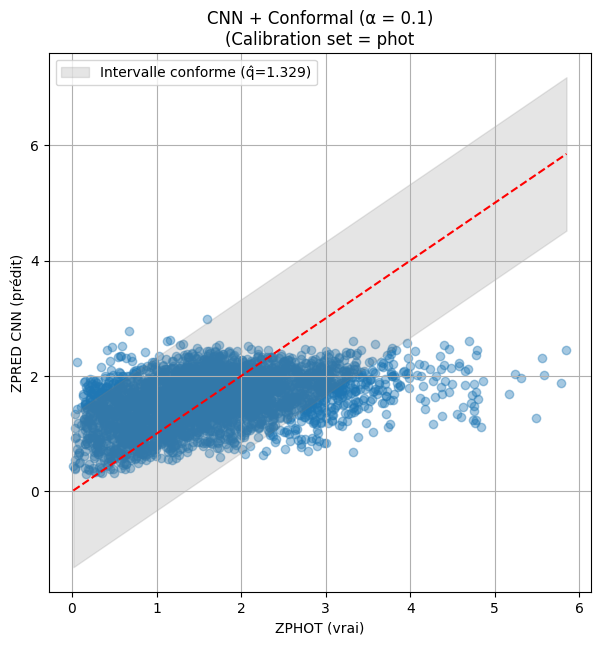

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

In [ ]:
q_hat = results_1[0.10]['q_hat']

y_pred_calib_cnn = model.predict(X_calib, verbose=0).ravel()
y_calib_range    = np.linspace(y_calib.min(), y_calib.max(), 100)

plt.figure(figsize=(7, 7))
plt.scatter(y_calib, y_pred_calib_cnn, alpha=0.4)
plt.plot(
    [y_calib.min(), y_calib.max()],
    [y_calib.min(), y_calib.max()],
    'r--'
)
plt.fill_between(
    y_calib_range,
    y_calib_range - q_hat,
    y_calib_range + q_hat,
    color='gray', alpha=0.2, label=f'Intervalle conforme (q̂={q_hat:.3f})'
)
plt.xlabel("ZPHOT (vrai)")
plt.ylabel("ZPRED CNN (prédit)")
plt.title(f"CNN + Conformal (α = 0.1)\n(Calibration set = phot")
plt.legend()
plt.grid(True)
plt.savefig("graphique_cnn_scatter_conforme.png", dpi=150, bbox_inches='tight')
plt.show()
files.download("graphique_cnn_scatter_conforme.png")

## Tableau récapitulatif

In [ ]:
print("Tableau récapitulatif - CNN + Conformal Prediction")

print(f"{'Approche':<30} {'α':>5} | {'Cible':>7} | {'Couverture':>11} | {'Largeur':>9}")
print("-" * 65)
for alpha in alphas:
    print(f"{'Valeurs directes':<30} {alpha:>5.2f} | {1-alpha:>7.2f} | "
          f"{results_1[alpha]['coverage']:>11.3f} | {results_1[alpha]['width']:>9.4f}")
print()
for alpha in alphas:
    print(f"{'Bins (Δz=0.1)':<30} {alpha:>5.2f} | {1-alpha:>7.2f} | "
          f"{results_2[alpha]['coverage']:>11.3f} | {results_2[alpha]['width']:>9.4f}")
print()
for alpha in alphas:
    dz_sigma = 1.4826 * np.median(np.abs(
        results_3[alpha]['dz_test'] - np.median(results_3[alpha]['dz_test'])
    ))
    print(f"{'Δz normalisé':<30} {alpha:>5.2f} | {1-alpha:>7.2f} | "
          f"{results_3[alpha]['coverage']:>11.3f} | {results_3[alpha]['q_hat']:>9.4f}  "
          f"(σ_NMAD={dz_sigma:.4f}  outliers={results_3[alpha]['outliers']:.3f})")

Tableau récapitulatif — CNN + Conformal Prediction
Approche                           α |   Cible |  Couverture |   Largeur
-----------------------------------------------------------------
Valeurs directes                0.05 |    0.95 |       0.778 |    3.2361
Valeurs directes                0.10 |    0.90 |       0.778 |    2.6578
Valeurs directes                0.15 |    0.85 |       0.667 |    2.2683
Valeurs directes                0.20 |    0.80 |       0.630 |    2.0168

Bins (Δz=0.1)                   0.05 |    0.95 |       0.778 |    2.6630
Bins (Δz=0.1)                   0.10 |    0.90 |       0.778 |    2.3111
Bins (Δz=0.1)                   0.15 |    0.85 |       0.667 |    2.0481
Bins (Δz=0.1)                   0.20 |    0.80 |       0.667 |    1.9037

Δz normalisé                    0.05 |    0.95 |       0.778 |    0.7595  (σ_NMAD=0.2596  outliers=0.889)
Δz normalisé                    0.10 |    0.90 |       0.704 |    0.5447  (σ_NMAD=0.2596  outliers=0.889)
Δz normalisé